# N2 vs N3 Infraslow Analysis Demo

Downstream analysis/visualization notebook over `infraslow.pipeline`'s already-computed
per-subject ISFS spectrum and phase features (see `src/scripts/preprocessing.py` for how
the underlying `.npz`/`.csv` artifacts under `/scratch/users/chaisaen/processed_data/data/`
were generated). No EEG filtering, spindle/slow-wave detection, or envelope computation
happens here -- every number below comes from `infraslow.pipeline.pipeline.run_subject_state_channel`
and `infraslow.stat.state_comparison`, reused unmodified from the rest of the project.

Compares **N2 vs N3** on channel **C3** across the first 10 subjects (sorted by id) with
usable spindle-containing bouts in both states.

## 1. Imports and Configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from infraslow.pipeline import pipeline as ppl
from infraslow.pipeline import phase as pph
from infraslow.processing.infraslow import (
    DEFAULT_INFRASLOW_BAND,
    DEFAULT_BASELINE_BAND,
    bigaussian,
    fit_isfs,
)
from infraslow.stat import state_comparison as stc

# infraslow.pipeline.pipeline transitively imports infraslow.pipeline.figures, which
# calls matplotlib.use("Agg") at import time (a headless-safe default for the batch
# pipeline) -- that forces a non-interactive backend, silently overriding an earlier
# `%matplotlib inline`. Issuing the magic here, after those imports, re-enables inline
# figure display in this notebook without touching the pre-existing pipeline module.
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
PURPLE, LPURPLE = '#5b2a86', '#c9b3e6'
ORANGE, LORANGE = '#d2691e', '#f2c14e'
COLORS = {"N2": (PURPLE, LPURPLE), "N3": (ORANGE, LORANGE)}

DATA_DIR = Path("/scratch/users/chaisaen/processed_data/data")
CHANNEL = "C3"
STATES = ("N2", "N3")
N_SUBJECTS = 10

## 2. Find Eligible Subjects

Sorted by id (`infraslow.pipeline.io.discover_subjects`'s own order, preserved by
`find_paired_subject_data`). `find_paired_subject_data` guarantees a non-`None`
**spectrum** record for every state in `STATES` (pairing preserved by construction,
not filtered independently per state) -- but a subject/state can still have a valid
spectrum record with `phase_bin_rates=None`, because
`infraslow.pipeline.phase.compute_subject_phase_features` separately (and by design,
see its docstring) excludes a subject/state with fewer than `DEFAULT_ISFS_MIN_EVENTS`
in-cycle spindle events from phase reporting, independent of whether its spectrum was
computable. Section 5 (phase analysis) needs `phase_bin_rates` on every selected
subject/state, so we pull a larger candidate pool from `find_paired_subject_data` and
filter down to the first `N_SUBJECTS` (still sorted by id) that also have usable phase
data in every state.

In [2]:
# CANDIDATE_LIMIT is a generous margin over N_SUBJECTS: empirically, on this cohort
# roughly half of subjects with a valid paired spectrum record also have usable phase
# data (>= DEFAULT_ISFS_MIN_EVENTS in-cycle spindle events) in every state -- 40
# candidates comfortably yields >= 10 phase-complete subjects.
CANDIDATE_LIMIT = 40
candidates = ppl.find_paired_subject_data(DATA_DIR, CHANNEL, STATES, limit=CANDIDATE_LIMIT)


def _has_phase_data(entry):
    return all(entry[state][0].get("phase_bin_rates") is not None for state in STATES)


phase_complete = {sid: data for sid, data in candidates.items() if _has_phase_data(data)}
paired_data = dict(list(phase_complete.items())[:N_SUBJECTS])
SUBJECT_IDS = list(paired_data)
assert len(SUBJECT_IDS) == N_SUBJECTS, (
    f"expected {N_SUBJECTS} paired subjects with usable spectrum AND phase data, "
    f"found {len(SUBJECT_IDS)} among {len(candidates)} spectrum-paired candidates "
    f"(try raising CANDIDATE_LIMIT)"
)

print(f"Selected {len(SUBJECT_IDS)} subjects with usable {'/'.join(STATES)} spectrum + phase "
      f"data on {CHANNEL} (out of {len(candidates)} spectrum-paired candidates checked):")
for sid in SUBJECT_IDS:
    print(f"  {sid}")

Selected 10 subjects with usable N2/N3 spectrum + phase data on C3 (out of 40 spectrum-paired candidates checked):
  317947
  318517
  318668
  318732
  318819
  318868
  318878
  318910
  318913
  318917


## 3. Load Subject Data

`paired_data` (from Section 2) already holds every `(record, bout_records, curves)` this
notebook needs -- no further disk I/O happens below. This section validates the expected
keys/shapes are present and assembles the two tidy per-state feature tables
(`n2_df`/`n3_df`) the rest of the notebook uses.

In [3]:
REQUIRED_RECORD_KEYS = {
    "subject_id", "sleep_state", "peak_freq_hz", "peak_period_s", "bandwidth_hz", "auc",
    "chromatogram_peak_area", "bi_gaussian_amp", "bi_gaussian_mu", "bi_gaussian_sd_l",
    "bi_gaussian_sd_r", "phase_bin_rates", "mean_phase", "resultant_length",
}
for sid in SUBJECT_IDS:
    for state in STATES:
        record, _bout_records, curves = paired_data[sid][state]
        missing = REQUIRED_RECORD_KEYS - record.keys()
        assert not missing, f"{sid}/{state} missing keys: {missing}"
        assert curves["freqs"].shape == curves["rel"].shape == curves["corrected"].shape
        assert len(record["phase_bin_rates"]) == 8

n2_df = pd.DataFrame([paired_data[sid]["N2"][0] for sid in SUBJECT_IDS])
n3_df = pd.DataFrame([paired_data[sid]["N3"][0] for sid in SUBJECT_IDS])
print(f"n2_df: {n2_df.shape}, n3_df: {n3_df.shape}")
print("All subject/state records contain the expected ISFS spectrum and phase keys.")

n2_df: (10, 35), n3_df: (10, 35)
All subject/state records contain the expected ISFS spectrum and phase keys.


## 4. N2 vs N3 ISFS Spectral Analysis

### 4.1 Subject-Level Spectra

In [4]:
# The frequency grid is fixed by preprocessing.py's WINDOW_SEC (not per-bout length),
# so every subject/state shares the same `freqs` -- verify that before stacking.
freqs = paired_data[SUBJECT_IDS[0]]["N2"][2]["freqs"]
for sid in SUBJECT_IDS:
    for state in STATES:
        assert np.allclose(paired_data[sid][state][2]["freqs"], freqs)

rel_by_state = {
    state: np.stack([paired_data[sid][state][2]["rel"] for sid in SUBJECT_IDS])
    for state in STATES
}
corrected_by_state = {
    state: np.stack([paired_data[sid][state][2]["corrected"] for sid in SUBJECT_IDS])
    for state in STATES
}
band_m = (freqs >= DEFAULT_INFRASLOW_BAND[0]) & (freqs <= DEFAULT_INFRASLOW_BAND[1])
{state: rel_by_state[state].shape for state in STATES}

{'N2': (10, 40), 'N3': (10, 40)}

### 4.2 Average Relative Spectral Power

In [5]:
# Subject-level average (not pooled): mean +/- SEM across the 10 subjects' own
# per-subject relative-power curves -- infraslow.stat.state_comparison.mean_sem.
rel_mean = {state: stc.mean_sem(rel_by_state[state]) for state in STATES}

### 4.3 Baseline Correction

Baseline correction (subtracting the mean power over `DEFAULT_BASELINE_BAND`) was already
applied per-subject/state by `infraslow.pipeline.spectrum.compute_subject_spectrum_features`
(via `infraslow.processing.infraslow.baseline_correct`) when `find_paired_subject_data` built
`paired_data` in Section 2 -- `corrected_by_state` (below) is that result, not recomputed.

In [6]:
corrected_mean = {state: stc.mean_sem(corrected_by_state[state]) for state in STATES}

### 4.4 Bi-Gaussian Fits

Each subject's own bi-Gaussian fit parameters are already in `n2_df`/`n3_df`
(`bi_gaussian_*`, `peak_freq_hz`, `bandwidth_hz`, `auc`, `chromatogram_peak_area` -- see
Section 6/7). For the group-comparison figure below, `fit_isfs` (unmodified, the same
function `infraslow.pipeline.spectrum.compute_subject_spectrum_features` calls per subject)
is applied once more directly to each state's **group-average** baseline-corrected
spectrum, giving one representative bi-Gaussian curve per state to overlay.

In [7]:
group_fit = {}
for state in STATES:
    mean_corrected = corrected_mean[state][0]
    group_fit[state] = fit_isfs(
        freqs, mean_corrected, infraslow_band=DEFAULT_INFRASLOW_BAND, baseline_band=DEFAULT_BASELINE_BAND,
    )
    fit = group_fit[state]
    print(f"{state} group fit: peak={fit['mu']:.4f} Hz (~{1/fit['mu']:.0f} s) | "
          f"bandwidth={fit['bandwidth']:.4f} Hz | detected={fit['detected']}")

N2 group fit: peak=0.0175 Hz (~57 s) | bandwidth=0.0728 Hz | detected=True
N3 group fit: peak=0.0100 Hz (~100 s) | bandwidth=0.0233 Hz | detected=True


#### Figure: N2 vs N3 average ISFS spectrum

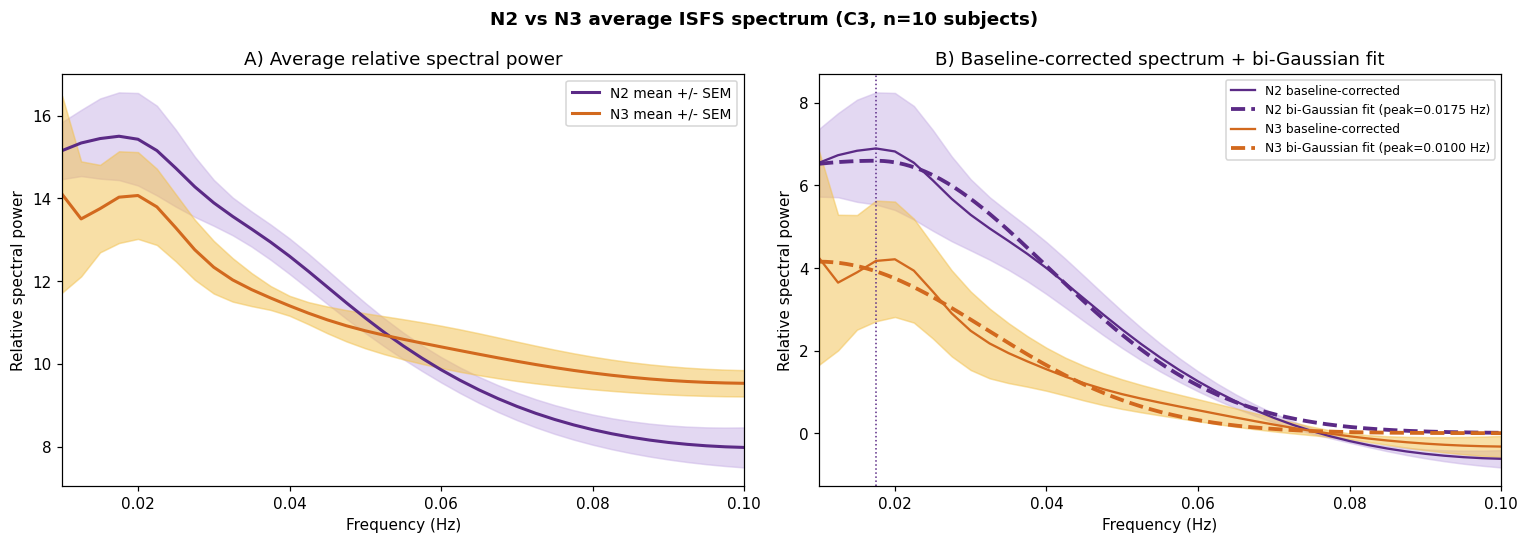

In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

for state in STATES:
    dark, light = COLORS[state]
    mean_rel, sem_rel = rel_mean[state]
    axL.fill_between(freqs[band_m], (mean_rel - sem_rel)[band_m], (mean_rel + sem_rel)[band_m],
                      color=light, alpha=0.5)
    axL.plot(freqs[band_m], mean_rel[band_m], color=dark, lw=2, label=f"{state} mean +/- SEM")
axL.set(xlim=DEFAULT_INFRASLOW_BAND, xlabel="Frequency (Hz)", ylabel="Relative spectral power",
        title="A) Average relative spectral power")
axL.legend(frameon=True, fontsize=9)

fg = np.linspace(*DEFAULT_INFRASLOW_BAND, 400)
for state in STATES:
    dark, light = COLORS[state]
    mean_corr, sem_corr = corrected_mean[state]
    fit = group_fit[state]
    axR.fill_between(freqs[band_m], (mean_corr - sem_corr)[band_m], (mean_corr + sem_corr)[band_m],
                      color=light, alpha=0.5)
    axR.plot(freqs[band_m], mean_corr[band_m], color=dark, lw=1.5, label=f"{state} baseline-corrected")
    axR.plot(fg, bigaussian(fg, *fit["popt"]), color=dark, lw=2.5, ls="--",
              label=f"{state} bi-Gaussian fit (peak={fit['mu']:.4f} Hz)")
    axR.axvline(fit["mu"], color=dark, lw=1, ls=":")
axR.set(xlim=DEFAULT_INFRASLOW_BAND, xlabel="Frequency (Hz)", ylabel="Relative spectral power",
        title="B) Baseline-corrected spectrum + bi-Gaussian fit")
axR.legend(frameon=True, fontsize=8)

fig.suptitle(f"N2 vs N3 average ISFS spectrum ({CHANNEL}, n={len(SUBJECT_IDS)} subjects)", fontweight="bold")
fig.tight_layout()

## 5. N2 vs N3 Spindle Phase Analysis

### 5.1 Subject-Level Phase Distributions

Each subject/state's 8-bin `phase_bin_rates` (already computed by
`infraslow.pipeline.phase.compute_subject_phase_features` inside `find_paired_subject_data`,
Section 2) is stacked into `(n_subjects, 8)` arrays; `bin_center_angle` (unmodified, from
`infraslow.pipeline.phase`) gives each bin's phase angle for the x-axis below.

In [9]:
phase_rates = {
    state: np.stack([paired_data[sid][state][0]["phase_bin_rates"] for sid in SUBJECT_IDS])
    for state in STATES
}
bin_centers = pph.bin_center_angle(np.arange(1, 9))
{state: phase_rates[state].shape for state in STATES}

{'N2': (10, 8), 'N3': (10, 8)}

### 5.2 Group Average Phase Distribution

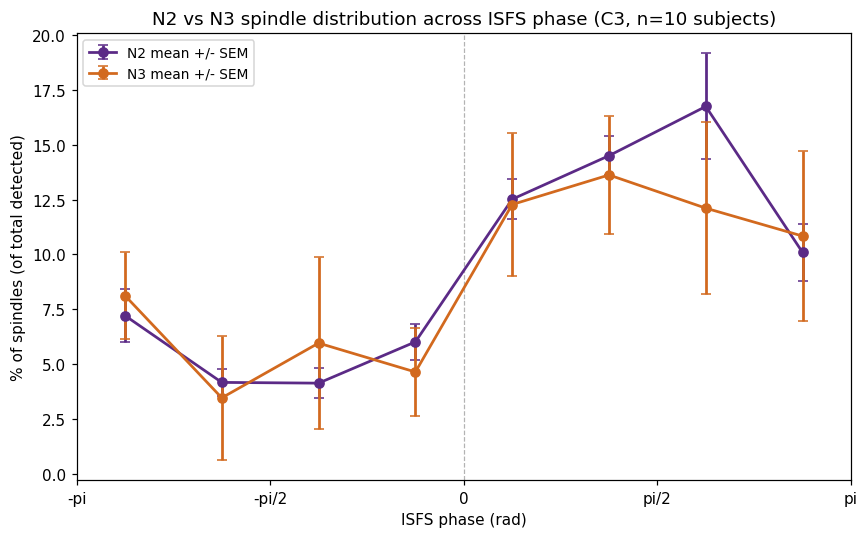

In [10]:
phase_mean = {state: stc.mean_sem(phase_rates[state]) for state in STATES}

fig, ax = plt.subplots(figsize=(8, 5))
for state in STATES:
    dark, light = COLORS[state]
    mean_r, sem_r = phase_mean[state]
    ax.errorbar(bin_centers, mean_r, yerr=sem_r, color=dark, marker="o", ms=6,
                capsize=3, lw=1.8, label=f"{state} mean +/- SEM")
ax.axvline(0, color="0.7", lw=0.8, ls="--")
ax.set(xlabel="ISFS phase (rad)", ylabel="% of spindles (of total detected)",
       xticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
       xticklabels=["-pi", "-pi/2", "0", "pi/2", "pi"],
       title=f"N2 vs N3 spindle distribution across ISFS phase ({CHANNEL}, n={len(SUBJECT_IDS)} subjects)")
ax.legend(frameon=True, fontsize=9)
fig.tight_layout()

## 6. Peak-Frequency Distribution

### 6.1 Distribution Plot

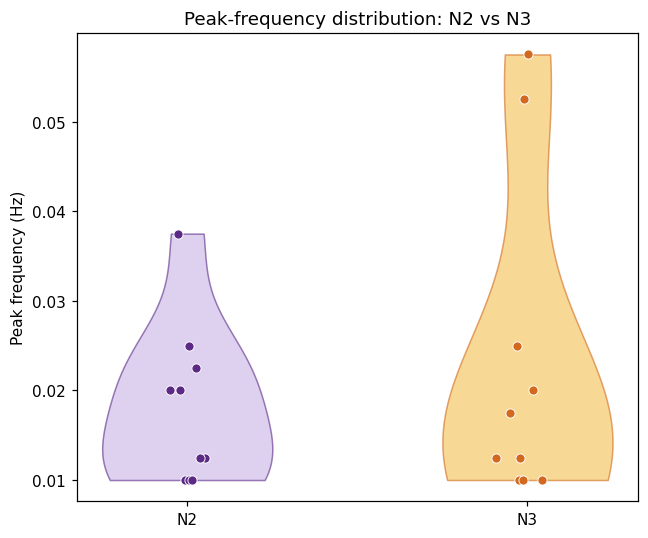

In [11]:
peak_freqs = {state: (n2_df if state == "N2" else n3_df)["peak_freq_hz"].to_numpy() for state in STATES}

fig, ax = plt.subplots(figsize=(6, 5))
positions = [1, 2]
parts = ax.violinplot([peak_freqs["N2"], peak_freqs["N3"]], positions=positions,
                       showmeans=False, showextrema=False)
for pc, state in zip(parts["bodies"], STATES):
    pc.set_facecolor(COLORS[state][1])
    pc.set_edgecolor(COLORS[state][0])
    pc.set_alpha(0.6)

rng = np.random.default_rng(0)
for pos, state in zip(positions, STATES):
    y = peak_freqs[state]
    x = rng.normal(pos, 0.04, size=y.size)
    ax.plot(x, y, "o", color=COLORS[state][0], ms=6, mec="white", mew=0.6, zorder=3)

ax.set(xticks=positions, xticklabels=STATES, ylabel="Peak frequency (Hz)",
       title="Peak-frequency distribution: N2 vs N3")
fig.tight_layout()

### 6.2 Paired Plot

,mean,sd,median,iqr
N2,0.01800,0.008882,0.01625,0.011250
N3,0.02275,0.017735,0.01500,0.013125


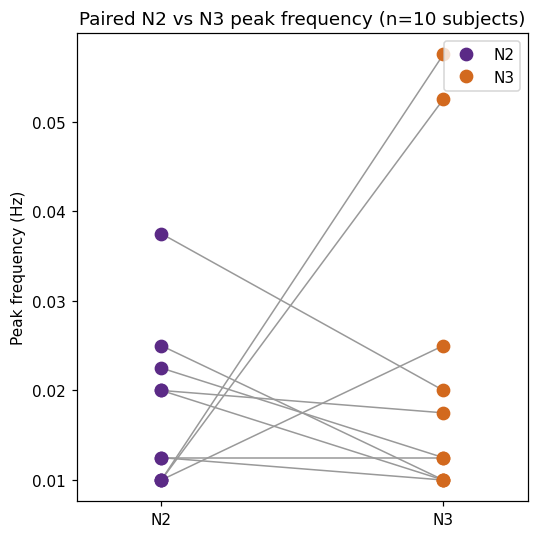

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
for n2_v, n3_v in zip(peak_freqs["N2"], peak_freqs["N3"]):
    ax.plot([1, 2], [n2_v, n3_v], color="0.6", lw=1.0, zorder=1)
ax.plot(np.ones_like(peak_freqs["N2"]), peak_freqs["N2"], "o", color=COLORS["N2"][0], ms=8,
        zorder=3, label="N2")
ax.plot(np.full_like(peak_freqs["N3"], 2), peak_freqs["N3"], "o", color=COLORS["N3"][0], ms=8,
        zorder=3, label="N3")
ax.set(xlim=(0.7, 2.3), xticks=[1, 2], xticklabels=STATES, ylabel="Peak frequency (Hz)",
       title=f"Paired N2 vs N3 peak frequency (n={len(SUBJECT_IDS)} subjects)")
ax.legend(frameon=True)
fig.tight_layout()

peak_freq_summary = pd.DataFrame({state: stc.describe(peak_freqs[state]) for state in STATES}).T
peak_freq_summary

## 7. Statistical Comparison

### 7.1 Peak Frequency

In [13]:
peak_ttest = stc.paired_ttest(n2_df["peak_freq_hz"].to_numpy(), n3_df["peak_freq_hz"].to_numpy())
peak_dz = stc.paired_effect_size(n2_df["peak_freq_hz"].to_numpy(), n3_df["peak_freq_hz"].to_numpy())

print(f"n={peak_ttest['n_pairs']} | N2 {peak_ttest['x_mean']:.4f}+/-{peak_ttest['x_sd']:.4f} Hz | "
      f"N3 {peak_ttest['y_mean']:.4f}+/-{peak_ttest['y_sd']:.4f} Hz | "
      f"mean diff={peak_ttest['mean_diff']:.4f} Hz | t={peak_ttest['t_stat']:.3f} | "
      f"p={peak_ttest['p_value']:.4g} | Cohen's dz={peak_dz:.3f}")

n=10 | N2 0.0180+/-0.0089 Hz | N3 0.0227+/-0.0177 Hz | mean diff=-0.0047 Hz | t=-0.650 | p=0.5319 | Cohen's dz=-0.206


### 7.2 Phase Bins

Paired t-test per ISFS phase bin (ordinary, on the bin-rate values -- not a circular test;
see the circular-preferred-phase supplement at the end of this section), BH-FDR corrected
across the 8 bins.

In [14]:
phase_bin_results = stc.compare_phase_bins(phase_rates["N2"], phase_rates["N3"], bin_centers)
phase_bin_results

,phase_bin,phase_center,N2_mean,N3_mean,mean_difference,n_pairs,t_stat,p_value,q_value,significant_FDR
0,1,-2.748894,7.222535,8.131888,-0.909353,10,-0.613869,0.554499,0.936587,False
1,2,-1.963495,4.184046,3.481279,0.702767,10,0.241189,0.814814,0.936587,False
2,3,-1.178097,4.150149,5.971597,-1.821448,10,-0.467180,0.651475,0.936587,False
3,4,-0.392699,6.026930,4.657326,1.369604,10,0.542700,0.600515,0.936587,False
4,5,0.392699,12.512699,12.272497,0.240202,10,0.081811,0.936587,0.936587,False
5,6,1.178097,14.492401,13.616449,0.875953,10,0.412087,0.689918,0.936587,False
6,7,1.963495,16.731178,12.106375,4.624802,10,1.690277,0.125236,0.936587,False
7,8,2.748894,10.092042,10.836818,-0.744776,10,-0.195702,0.849190,0.936587,False


### 7.3 Other ISFS Metrics

In [15]:
ISFS_METRICS = {
    "peak_freq_hz": "peak_frequency_hz",
    "peak_period_s": "peak_period_s",
    "bi_gaussian_amp": "amplitude",
    "bi_gaussian_sd_l": "sd_left",
    "bi_gaussian_sd_r": "sd_right",
    "bandwidth_hz": "bandwidth_hz",
    "auc": "auc",
    "chromatogram_peak_area": "chromatogram_peak_area",
}
isfs_metric_results = stc.compare_isfs_metrics(n2_df, n3_df, ISFS_METRICS)
isfs_metric_results

,Metric,N2 Mean,N2 SD,N3 Mean,N3 SD,Mean Difference,t,p,n_pairs,Cohen's dz,q
0,peak_frequency_hz,0.018000,0.008882,0.022750,0.017735,-0.004750,-0.650040,0.531906,10,-0.205561,0.709208
1,peak_period_s,67.111111,27.982946,64.358178,32.336468,2.752933,0.164319,0.873111,10,0.051962,0.873111
2,amplitude,7.802685,3.034412,6.520598,5.294710,1.282086,0.708352,0.496662,10,0.224001,0.709208
3,sd_left,0.016226,0.014919,0.010891,0.013260,0.005335,0.707059,0.497428,10,0.223592,0.709208
4,sd_right,0.017807,0.010817,0.015568,0.013167,0.002239,0.369855,0.720044,10,0.116958,0.822908
5,bandwidth_hz,0.034033,0.017497,0.026460,0.022180,0.007574,0.751880,0.471328,10,0.237765,0.709208
6,auc,0.241459,0.161752,0.125490,0.130901,0.115968,1.701926,0.122977,10,0.538196,0.709208
7,chromatogram_peak_area,0.068245,0.056980,0.039944,0.062434,0.028301,1.250028,0.242815,10,0.395293,0.709208


#### Supplemental: circular preferred-phase comparison

`mean_phase` (each subject/state's own circular mean of in-cycle event angles, already
computed by `infraslow.pipeline.phase.compute_subject_phase_features`) is a circular
quantity -- a linear paired t-test on raw `(-pi, pi]` angles is not meaningful. This reports
the cohort's circular mean/resultant length per state instead, as a supplement to Section
7.2's ordinary (non-circular) phase-bin-rate paired tests, not a replacement for them.

In [16]:
n2_circ = stc.circular_mean_and_resultant(n2_df["mean_phase"].to_numpy())
n3_circ = stc.circular_mean_and_resultant(n3_df["mean_phase"].to_numpy())
print(f"N2 circular mean phase = {n2_circ[0]:.3f} rad, resultant length = {n2_circ[1]:.3f}")
print(f"N3 circular mean phase = {n3_circ[0]:.3f} rad, resultant length = {n3_circ[1]:.3f}")

N2 circular mean phase = 1.552 rad, resultant length = 0.979
N3 circular mean phase = 1.451 rad, resultant length = 0.632


## 8. Summary

In [17]:
n_sig_bins = int(phase_bin_results["significant_FDR"].sum())
n_sig_metrics = int((isfs_metric_results["q"] < 0.05).sum())

print("Summary")
print("=======")
print(f"Subjects: {len(SUBJECT_IDS)} (channel {CHANNEL}), paired N2/N3 usable data")
print(f"Peak frequency: N2 {peak_ttest['x_mean']:.4f} Hz vs N3 {peak_ttest['y_mean']:.4f} Hz, "
      f"t({peak_ttest['n_pairs'] - 1})={peak_ttest['t_stat']:.3f}, p={peak_ttest['p_value']:.4g}, "
      f"Cohen's dz={peak_dz:.3f}")
print(f"Phase bins significant after FDR (q<0.05): {n_sig_bins}/8")
print(f"ISFS metrics significant after FDR (q<0.05): {n_sig_metrics}/{len(isfs_metric_results)}")
print(f"N2 circular mean phase: {n2_circ[0]:.3f} rad (resultant {n2_circ[1]:.3f})")
print(f"N3 circular mean phase: {n3_circ[0]:.3f} rad (resultant {n3_circ[1]:.3f})")

Summary
Subjects: 10 (channel C3), paired N2/N3 usable data
Peak frequency: N2 0.0180 Hz vs N3 0.0227 Hz, t(9)=-0.650, p=0.5319, Cohen's dz=-0.206
Phase bins significant after FDR (q<0.05): 0/8
ISFS metrics significant after FDR (q<0.05): 0/8
N2 circular mean phase: 1.552 rad (resultant 0.979)
N3 circular mean phase: 1.451 rad (resultant 0.632)
